In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [2]:
# 1. Carga e Informações Gerais
data = load_breast_cancer()
X, y = data.data, data.target
print(f"Shape: {X.shape}")
print(f"Classes: {data.target_names}")
print(f"Features (exemplo): {data.feature_names[:3]}")

Shape: (569, 30)
Classes: ['malignant' 'benign']
Features (exemplo): ['mean radius' 'mean texture' 'mean perimeter']


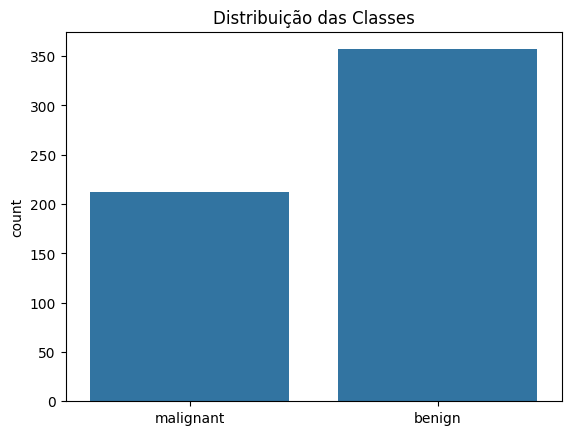

In [3]:
# 2. Gráfico Exploratório
sns.countplot(x=y)
plt.xticks(ticks=[0, 1], labels=data.target_names)
plt.title("Distribuição das Classes")
plt.show()

In [4]:
# 3. Divisão e Pré-processamento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# 4. Treinamento de K = 1 a 20
accuracies = []
k_values = range(1, 21)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accuracies.append(knn.score(X_test_scaled, y_test))

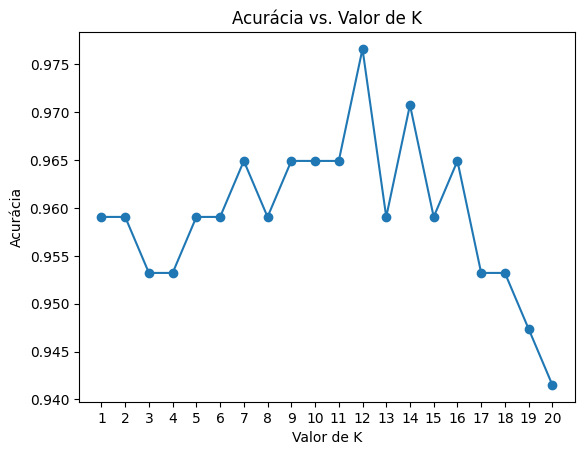

In [6]:
# 5. Gráfico de Acurácia x K
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('Valor de K')
plt.ylabel('Acurácia')
plt.title('Acurácia vs. Valor de K')
plt.xticks(k_values)
plt.show()

In [ ]:
# 6. Modelo Final
best_k = k_values[accuracies.index(max(accuracies))]
print(f"Melhor K escolhido: {best_k}")

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
preds = knn_final.predict(X_test_scaled)

print(classification_report(y_test, preds, target_names=data.target_names))

Melhor K escolhido: 12
              precision    recall  f1-score   support

   malignant       1.00      0.94      0.97        64
      benign       0.96      1.00      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171

